In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

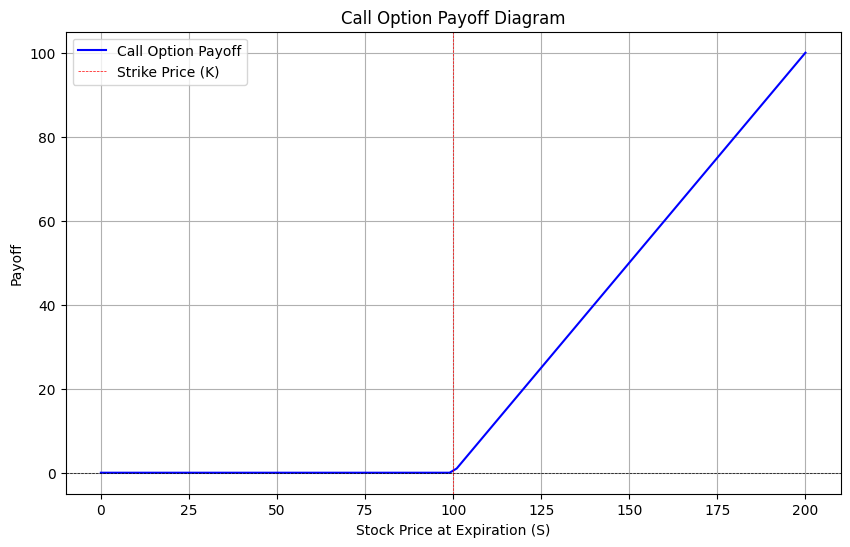

In [3]:
## Call option payoff diagram

def call_option_payoff(S, K):
    return np.maximum(S - K, 0)

S = np.linspace(0, 200, 100)
K = 100
payoff = call_option_payoff(S, K)   

plt.figure(figsize=(10, 6))
plt.plot(S, payoff, label='Call Option Payoff', color='blue')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(K, color='red', lw=0.5, ls='--', label='Strike Price (K)')
plt.title('Call Option Payoff Diagram')
plt.xlabel('Stock Price at Expiration (S)')
plt.ylabel('Payoff')
plt.legend()
plt.grid()



In [3]:

# 2-step binomial model for a European call

def european_call_binomial(S0, K, rb, u, d, T):
    # risk-neutral probability
    p = (np.exp(rb * T) - d) / (u - d)

    # stock prices at maturity (t=2)
    Suu = S0 * u * u
    Sud = S0 * u * d
    Sdd = S0 * d * d

    # option payoffs at t=2
    Cu = max(Suu - K, 0)
    Cm = max(Sud - K, 0)
    Cd = max(Sdd - K, 0)

    # step back to t=1
    C_u1 = np.exp(-rb * T) * (p * Cu + (1 - p) * Cm)
    C_d1 = np.exp(-rb * T) * (p * Cm + (1 - p) * Cd)

    # step back to t=0
    C0 = np.exp(-rb * T) * (p * C_u1 + (1 - p) * C_d1)
    return C0

def european_put_binomial(S0, K, rb, u, d, T):
    # risk-neutral probability
    p = (np.exp(rb * T) - d) / (u - d)

    # stock prices at maturity (t=2)
    Suu = S0 * u * u
    Sud = S0 * u * d
    Sdd = S0 * d * d

    # option payoffs at t=2
    Cu = max(K - Suu, 0)
    Cm = max(K - Sud, 0)
    Cd = max(K - Sdd, 0)

    # step back to t=1
    C_u1 = np.exp(-rb * T) * (p * Cu + (1 - p) * Cm)
    C_d1 = np.exp(-rb * T) * (p * Cm + (1 - p) * Cd)

    # step back to t=0
    C0 = np.exp(-rb * T) * (p * C_u1 + (1 - p) * C_d1)
    return C0

# example usage
S0 = 20
K = 21
rb = 0.15
u = 1.1
d = 0.9

T = 2/12  # two- month steps
price_call = european_call_binomial(S0, K, rb, u, d, T)
price_put = european_put_binomial(S0, K, rb, u, d, T)
print(f"2-step binomial European call price: {price_call:.4f}")
print(f"2-step binomial European put price: {price_put:.4f}")


2-step binomial European call price: 1.1950
2-step binomial European put price: 1.1709


In [7]:
import math

def binomial_option_price(
    S0, K, T, r, sigma, steps=200, option_type="call", exercise="european"
):
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp(r * dt) - d) / (u - d)
    disc = math.exp(-r * dt)

    if not (0 <= p <= 1):
        raise ValueError("Arbitrage detected: choose different step size/inputs.")

    # terminal stock prices at maturity
    j = np.arange(steps + 1)
    ST = S0 * (u ** j) * (d ** (steps - j))

    if option_type == "call":
        values = np.maximum(ST - K, 0.0)
    elif option_type == "put":
        values = np.maximum(K - ST, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    # backward induction
    for i in range(steps - 1, -1, -1):
        values = disc * (p * values[1:i + 2] + (1 - p) * values[0:i + 1])

        if exercise == "american":
            jj = np.arange(i + 1)
            Si = S0 * (u ** jj) * (d ** (i - jj))
            intrinsic = np.maximum(Si - K, 0.0) if option_type == "call" else np.maximum(K - Si, 0.0)
            values = np.maximum(values, intrinsic)
        elif exercise != "european":
            raise ValueError("exercise must be 'european' or 'american'.")

    return float(values[0])


def monte_carlo_option_price(
    S0, K, T, r, sigma, n_paths=200_000, option_type="call", seed=42
):
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_paths)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * math.sqrt(T) * z)

    if option_type == "call":
        payoffs = np.maximum(ST - K, 0.0)
    elif option_type == "put":
        payoffs = np.maximum(K - ST, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    discounted = math.exp(-r * T) * payoffs
    price = discounted.mean()
    std_error = discounted.std(ddof=1) / math.sqrt(n_paths)
    return float(price), float(std_error)


# Example
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2

binom_call = binomial_option_price(S0, K, T, r, sigma, steps=400, option_type="call")
binom_put_am = binomial_option_price(S0, K, T, r, sigma, steps=400, option_type="put", exercise="american")

mc_call, mc_se = monte_carlo_option_price(S0, K, T, r, sigma, option_type="call")

print(f"Binomial European Call: {binom_call:.4f}")
print(f"Binomial American Put:  {binom_put_am:.4f}")
print(f"Monte Carlo Call:       {mc_call:.4f} ± {1.96 * mc_se:.4f} (95% CI)")


Binomial European Call: 10.4456
Binomial American Put:  6.0884
Monte Carlo Call:       10.4634 ± 0.0649 (95% CI)


In [8]:
# Black-Scholes-Merton analytical price for a European call
def black_scholes_merton_call(S0, K, T, r, sigma, q=0.0):
    d1 = (math.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * math.exp(-q * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

# Example
S0, K, T, r, sigma, q = 100, 100, 1.0, 0.05, 0.2, 0.0
bsm_call = black_scholes_merton_call(S0, K, T, r, sigma, q)
print(f"Black-Scholes-Merton European Call: {bsm_call:.4f}")


Black-Scholes-Merton European Call: 10.4506


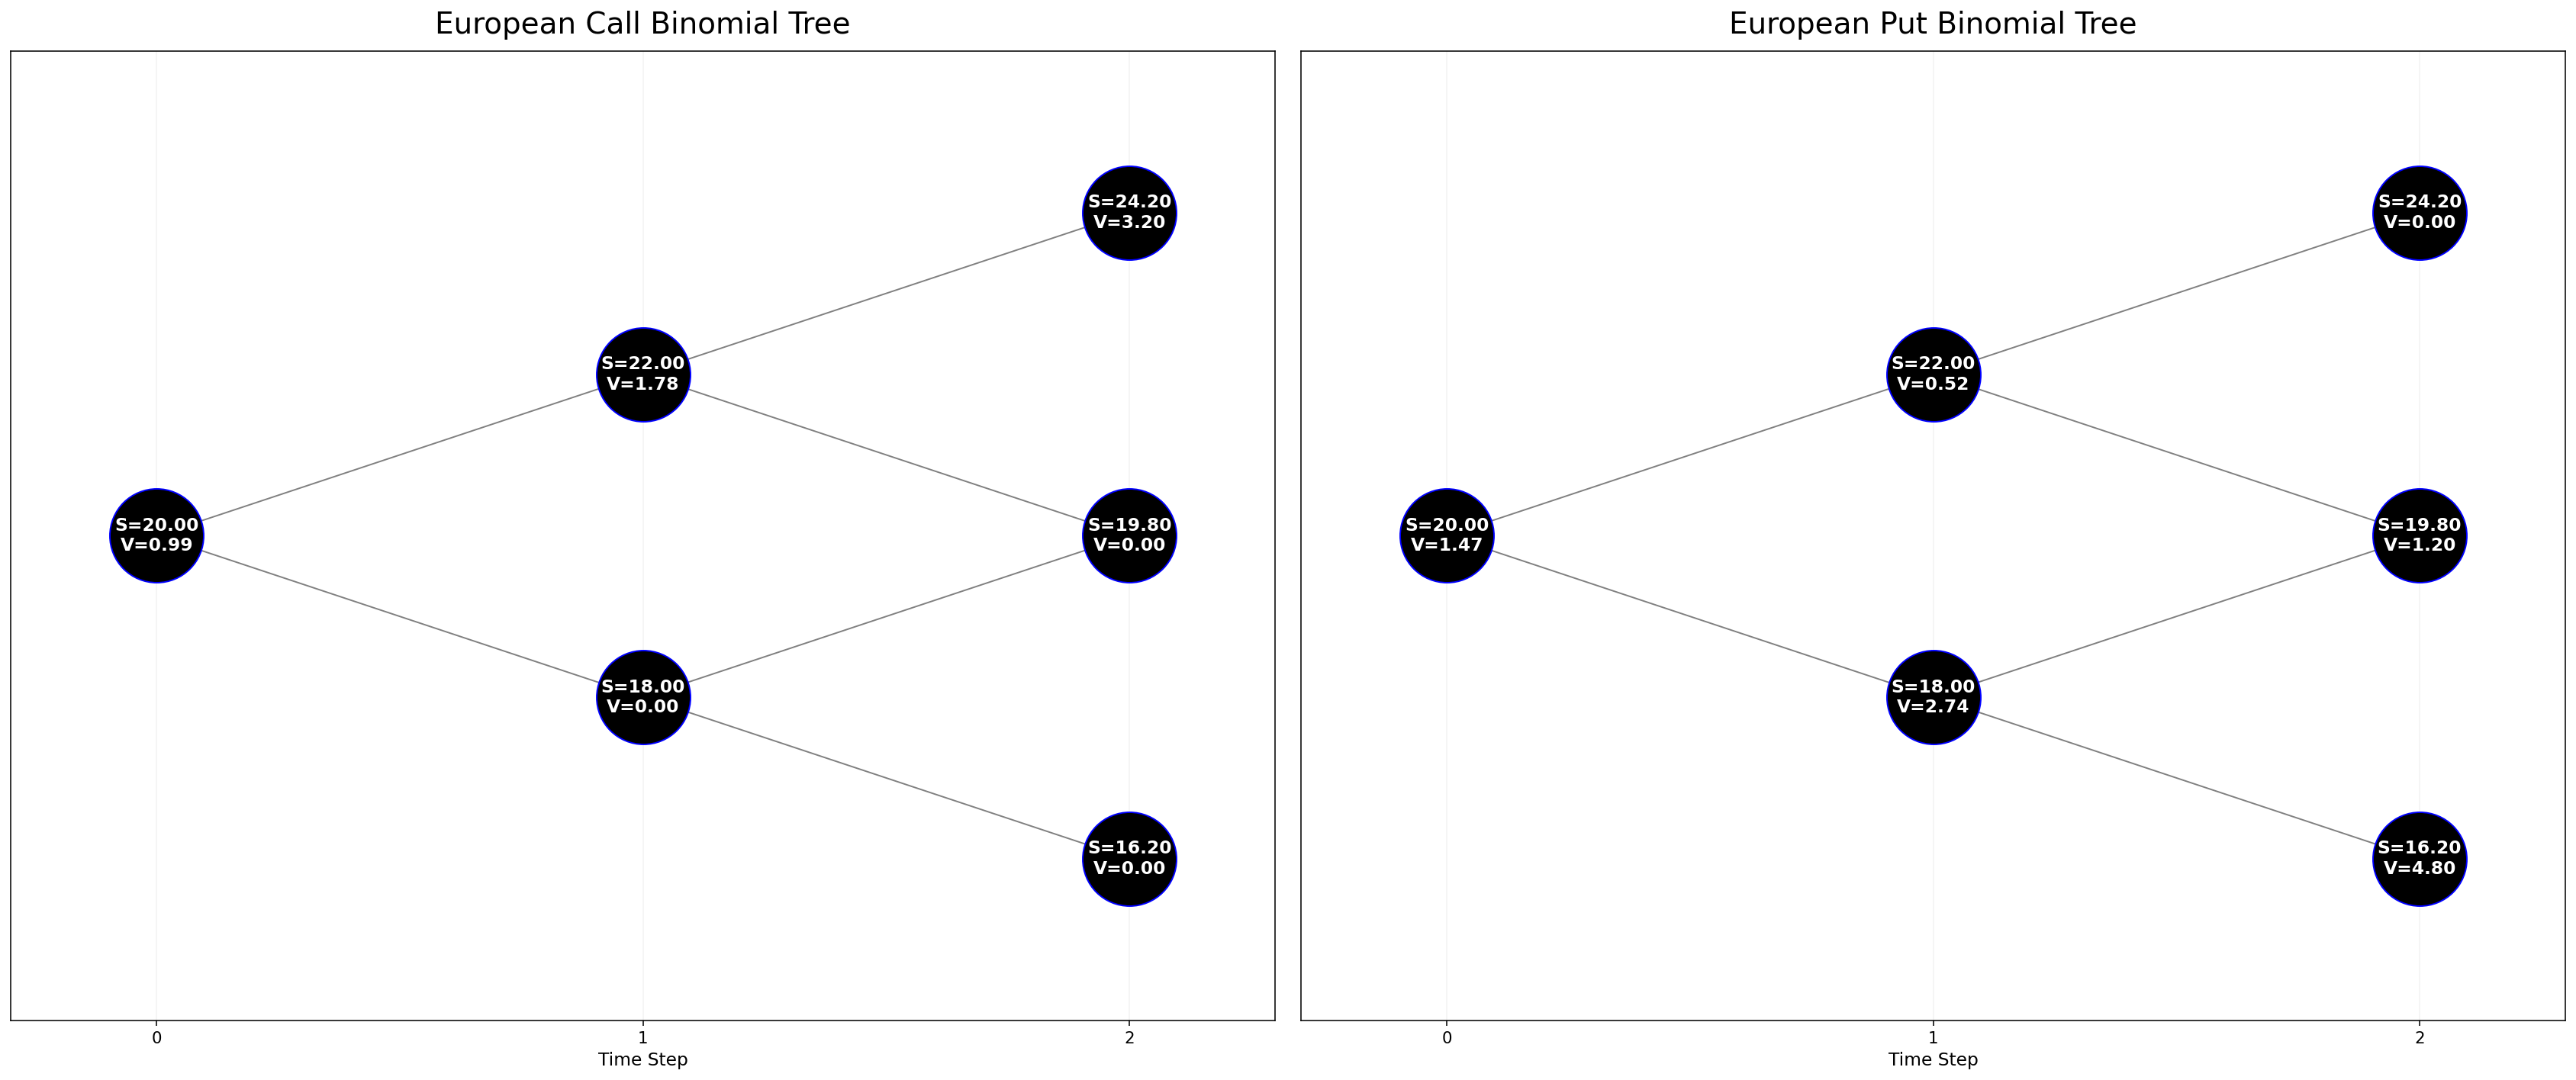

In [28]:
# Visualize binomial trees with option values at each node (European call and put)
# new function that uses recursion to print a K-step binomial tree

def build_stock_tree(S0, u, d, steps):
    return [[S0 * (u ** j) * (d ** (i - j)) for j in range(i + 1)] for i in range(steps + 1)]

def build_option_tree(stock_tree, K, r, dt, u, d, option_type="call"):
    steps = len(stock_tree) - 1
    option_tree = [[0.0] * (i + 1) for i in range(steps + 1)]

    if option_type == "call":
        option_tree[steps] = [max(s - K, 0.0) for s in stock_tree[steps]]
    elif option_type == "put":
        option_tree[steps] = [max(K - s, 0.0) for s in stock_tree[steps]]
    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    p = (math.exp(r * dt) - d) / (u - d)
    disc = math.exp(-r * dt)

    for i in range(steps - 1, -1, -1):
        for j in range(i + 1):
            continuation = p * option_tree[i + 1][j + 1] + (1 - p) * option_tree[i + 1][j]
            option_tree[i][j] = disc * continuation

    return option_tree

def plot_tree(ax, stock_tree, option_tree, title, y_scale=2.8):
    steps = len(stock_tree) - 1

    # Draw edges first
    for i in range(steps):
        for j in range(i + 1):
            x0, y0 = i, y_scale * (2 * j - i)
            x_up, y_up = i + 1, y_scale * (2 * (j + 1) - (i + 1))
            x_dn, y_dn = i + 1, y_scale * (2 * j - (i + 1))
            ax.plot([x0, x_up], [y0, y_up], color="gray", lw=1)
            ax.plot([x0, x_dn], [y0, y_dn], color="gray", lw=1)

    # Draw and label nodes
    for i in range(steps + 1):
        for j in range(i + 1):
            x, y = i, y_scale * (2 * j - i)
            s_val = stock_tree[i][j]
            v_val = option_tree[i][j]
            ax.scatter(x, y, s=4000, color="black", edgecolor="blue", zorder=3)
            ax.text(x, y, f"S={s_val:.2f}\nV={v_val:.2f}", ha="center", fontweight="bold", va="center", fontsize=12, color="white", zorder=4)

    ax.set_title(title, fontsize=20, pad=12)
    ax.set_xlabel("Time Step", fontsize=12)
    ax.set_xticks(range(steps + 1))
    ax.tick_params(axis="x", labelsize=11)
    ax.set_yticks([])
    ax.grid(alpha=0.15)

# Parameters
S0 = 20
K = 21
rb = 0.15
u = 1.1
d = 0.9
T = 2 / 12
steps = 2
dt = T / steps

stock_tree = build_stock_tree(S0, u, d, steps)
call_tree = build_option_tree(stock_tree, K, rb, dt, u, d, option_type="call")
put_tree = build_option_tree(stock_tree, K, rb, dt, u, d, option_type="put")

fig, axes = plt.subplots(1, 2, figsize=(24, 10), dpi=140, constrained_layout=True)
plot_tree(axes[0], stock_tree, call_tree, "European Call Binomial Tree")
plot_tree(axes[1], stock_tree, put_tree, "European Put Binomial Tree")

for ax in axes:
    ax.margins(x=0.15, y=0.25)
plt.show()
